In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# reading with csv file
movies =pd.read_csv('movies_updated.csv')

In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   object 
 1   rating     3960 non-null   object 
 2   genre      4000 non-null   object 
 3   year       4000 non-null   int64  
 4   released   4000 non-null   object 
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   object 
 8   writer     3999 non-null   object 
 9   star       3999 non-null   object 
 10  country    4000 non-null   object 
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   object 
 14  runtime,,  4000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 468.9+ KB


In [67]:
# Exercise 1
#1. Create a new feature called ROI: ROI = (gross - budget) / budget
roiTable = movies[["name" , "gross" , "budget","votes" , "score","genre"]].copy()
print(roiTable.count())

#2. Remove movies with missing values in budget , gross , or score .
print("--- replacing the missing values from each column ---")
roiTable.loc[:, "budget"] = np.where(roiTable["budget"] == 0, np.nan, roiTable["budget"])
roiTable.loc[:, "score"] = np.where(roiTable["score"] == 0, np.nan, roiTable["score"])
print(roiTable)

name      4000
gross     3831
budget    4000
votes     4000
score     4000
genre     4000
dtype: int64
--- replacing the missing values from each column ---
                                                name        gross      budget  \
0                                        The Shining   46998772.0  19000000.0   
1                                    The Blue Lagoon   58853106.0   4500000.0   
2     Star Wars: Episode V - The Empire Strikes Back  538375067.0  18000000.0   
3                                          Airplane!   83453539.0   3500000.0   
4                                         Caddyshack   39846344.0   6000000.0   
...                                              ...          ...         ...   
3995                                   Birthday Girl   16171098.0  13000000.0   
3996                                    Human Nature    1574660.0         NaN   
3997                                            Made    5480653.0   5000000.0   
3998                           On

C:\Users\ISUG\AppData\Local\Temp\ipykernel_23248\583904615.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[19000000.  4500000. 18000000. ...  5000000. 18000000. 70000000.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  roiTable.loc[:, "budget"] = np.where(roiTable["budget"] == 0, np.nan, roiTable["budget"])


In [46]:
print("--- Couting befor and after removing the missing values from each column ---")
print(roiTable.isnull().sum())
roiTable = roiTable.dropna() 
print(roiTable.isnull().sum())

--- Couting befor and after removing the missing values from each column ---
name         0
gross      169
budget    1392
votes        0
score        0
ROI       1441
dtype: int64
name      0
gross     0
budget    0
votes     0
score     0
ROI       0
dtype: int64


In [47]:
roiTable["ROI"] = (roiTable["gross"] - roiTable["budget"]) / roiTable["budget"]
roiTable

C:\Users\ISUG\AppData\Local\Temp\ipykernel_23248\4250578786.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roiTable["ROI"] = (roiTable["gross"] - roiTable["budget"]) / roiTable["budget"]


,name,gross,budget,votes,score,ROI
0,The Shining,46998772.0,19000000.0,927000,8.4,1.473620
1,The Blue Lagoon,58853106.0,4500000.0,65000,5.8,12.078468
2,Star Wars: Episode V - The Empire Strikes Back,538375067.0,18000000.0,1200000,8.7,28.909726
3,Airplane!,83453539.0,3500000.0,221000,7.7,22.843868
4,Caddyshack,39846344.0,6000000.0,108000,7.3,5.641057
...,...,...,...,...,...,...
3994,O,19260537.0,5000000.0,19000,6.1,2.852107
3995,Birthday Girl,16171098.0,13000000.0,25000,6.1,0.243931
3997,Made,5480653.0,5000000.0,18000,6.4,0.096131
3998,One Night at McCool's,13578186.0,18000000.0,29000,6.1,-0.245656


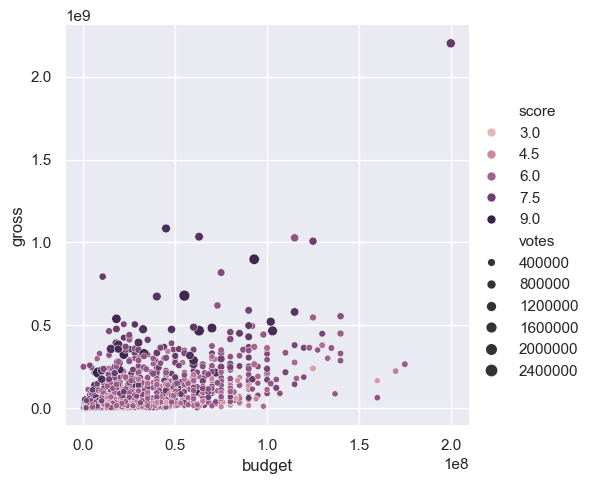

In [48]:
#3. Create a scatter plot that simultaneously shows:
sns.set_theme()
#3. Create a scatter plot that simultaneously shows:
sns.set_theme()
sns.relplot(data=roiTable, x="budget", y="gross", hue="score", size="votes")

In [63]:
#5. Identify and annotate the 10 movies with the highest ROI.
topTenROI= roiTable.nlargest(10, "ROI")
topTenROI

,name,gross,budget,votes,score,ROI
3459,The Blair Witch Project,248639099.0,60000.0,239000,6.5,4142.984983
2093,El Mariachi,2040920.0,7000.0,64000,6.9,290.560000
2467,Clerks,3151130.0,27000.0,214000,7.7,115.708519
3233,In the Company of Men,2804473.0,25000.0,13000,7.2,111.178920
209,E.T. the Extra-Terrestrial,792910554.0,10500000.0,381000,7.8,74.515291
3089,The Full Monty,257938649.0,3500000.0,101000,7.2,72.696757
5,Friday the 13th,39754601.0,550000.0,123000,6.4,71.281093
2458,Four Weddings and a Funeral,245700832.0,4400000.0,144000,7.1,54.841098
3291,Pi,3221152.0,60000.0,173000,7.4,52.685867
1684,Slacker,1228108.0,23000.0,20000,7.1,52.396000


In [66]:
#6. Create a second visualization that compares ROI distributions across the top 10 genres by movie count.
plt.figure(figsize=(12, 8))
sns.boxplot(data=topTenROI, x='genre', y='ROI')
plt.title('ROI Distribution Across Top 10 Genres by Movie Count')
plt.xlabel('Genre')
plt.ylabel('ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `genre` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x800 with 0 Axes>